# Quick start guide to generate and run YOLOv5 on MPPA with KANN

### GENERATE
First step is to GENERATE an intermediate representation of your neural network to run on the MPPA. In this notebook, we propose you to generate a YOLOv5 from ultralytics (https://github.com/ultralytics/ultralytics), already prepared for you in this repository.

In [2]:
%%bash
kann generate ../networks/object-detection/yolov5/onnx/yolov5su_f16.yaml -d yolov5s -f

[INFO]  ===> KaNN version: 5.6.0
[INFO]  ===> OpSet version: 1
[WARNING]  Kalray/yolov5/yolov5su.onnx does not exist, trying to find the model via huggingface hub
[INFO]  Downloading model from 🤗 => Kalray/yolov5/yolov5su.onnx ...
[INFO]  ===> DUMPING NETWORK'S YAML
[INFO]  ===> KaNN GRAPH CREATION
[INFO]  Neural Network Name : KaNNv5.6.0-yolov5su-fp16-5c
[INFO]  ===> KaNN GRAPH PARSING
[WARNING] Missing Module: No module kann_custom_layers found.
[INFO]  Convert to ONNX opset 20...
[INFO]  Optimize ONNX model...
[INFO]  ~> Saving Optimized Model to ./yolov5s/optimized-model.onnx
[WARNING] Unsupported Attribute: KaNN doesn't support 'extrapolation_value' attribute for layer (/model.11/Resize_output_0), attribute will be ignored.
[WARNING] Unsupported Attribute: KaNN doesn't support 'exclude_outside' attribute for layer (/model.11/Resize_output_0), attribute will be ignored.
[WARNING] Unsupported Attribute: KaNN doesn't support 'extrapolation_value' attribute for layer (/model.15/Resize

Generation: 100%|█████████████████████████████| 662/662 [00:15<00:00, 42.09it/s]


[INFO]  
[INFO]  ===> OPERATION STATISTICS
[INFO]    flop(s) required:  24.4805 G flop(s)
[INFO]    fma in convolutions: 11.9977 GFMA(s)
[INFO]  
[INFO]  ===> PERSISTENT DATA STATISTICS
[INFO]    # of layers whose parameters are persistent in SMEM:      3/182
[INFO]    amount of parameters that are persistent in SMEM:    4.4 KB/27.7 MB
[INFO]    # of layers whose parameters in DDR:                  179/182
[INFO]    amount of parameters that are in DDR:                27.7 MB/27.7 MB
[INFO]  
[INFO]  ===> MEMORY STATISTICS
[INFO]    total transfer from DDR:              32.6 MB
[INFO]    total transfer to DDR:                2.8 MB
[INFO]    total broadcast transfers (src/dst):   27.5 MB / 137.7 MB
[INFO]    detail transfer from DDR:              0: 28.7 MB   1: 990.7 KB  2: 990.7 KB  3: 990.7 KB  4: 975.4 KB  
[INFO]    detail transfer to DDR:                0: 2.8 MB    
[INFO]    transfer between clusters over NoC: 110.2 MB
[INFO]    max data sent by a cluster:     27.5 MB
[INFO]   

### EXECUTE on MPPA
Once the model has been generated, you could use it with a prepared script and host application to run it on the MPPA. The script `run` would introduce you 2 modes:
* `./run infer <model>` to evaluate the performance of the generated model on the MPPA
* `./run demo  <model> <source>` to evaluate the neural network predictions and performance into a video/image pipeline

#### Evaluate the neural network performance on the MPPA and HOST

In [3]:
%%bash
kann run ./yolov5s --nb-frames=10

[INFO]  ---------------------------------------------------------------------
[INFO]  ##### INPUT MANAGEMENT #####
[INFO]  Generation of 10 frames for each input ('random' mode).
[INFO]  ~> Generated inputs have been written in 'inputs_outputs_kann_yolov5s'
[INFO]  ---------------------------------------------------------------------
[INFO]  ##### MPPA RUNTIME #####
[INFO]  Command run: kann_opencl_cnn /work1/qmuller/modelsKalray/notebooks/yolov5s/KaNNv5.6.0-yolov5su-fp16-5c.kann inputs_outputs_kann_yolov5s
[app] Creating instance of KaNN::Service.
[KaNN_service] Calling constructor with /work1/qmuller/modelsKalray/notebooks/yolov5s/KaNNv5.6.0-yolov5su-fp16-5c.kann
[KaNN_service] Instance "KaNNv5.6.0-yolov5su-fp16-5c": created
[app] Creating an instance of KaNN::Service for a network requiring 5 clusters
[app] Accessing default platform
[app] Accessing all acceleration devices available on the platform
[app] Found 1 devices
[app] Accessing the device n°0 (serial P6AM67A-7E-009) in the 

Read the performance on the device (MPPA) and from the host application included in the KALRAY toolchain (kann_opencl_cnn). The host application in this case is not fully optimized, but give you a proper view of the runtime. Please contact our services at <support@kalrayinc.com> for more details to deploy your solution.

In [10]:
%%bash
../run infer ./yolov5s --nb-frames=10

/work1/qmuller/modelsKalray/utils/kann_run.py infer ./yolov5s --nb-frames=10
INFO: Find /work1/qmuller/kaf/kann/build_local_cv2/bin/kann_opencl_cnn as host application
INFO: 
INFO: ---------------------------
INFO:  Evaluating HW environment:
INFO: ---------------------------
INFO: [✅] HW revision found:  kv3-2
INFO: [✅] HW board :          k300-rev0x00 | 1FH24010240037
INFO: [✅] Driver version:     MPPA Driver PCIe Version:2.2.0
INFO: [✅] Cluster freq (MHz): [1000. 1000. 1000. 1000. 1000.]
INFO: 
INFO: ---------------------------
INFO:  Evaluating SW environment:
INFO: ---------------------------
INFO: [✅] Binary file:   /work1/qmuller/kaf/kann/build_local_cv2/bin/kann_opencl_cnn
INFO: [✅] Kernel file:   /work1/qmuller/kaf/kann/build_local_cv2/opencl_kernels/mppa_kann_opencl.cl.pocl
INFO: [!!] ACE release :  /work1/qmuller/kaf/kEnv/kvxtools/opt/kalray/accesscore - 6.1.0
INFO: [!!] KaNN(TM) :     /work1/qmuller/kaf/kann/python/kann - 5.6.0
INFO: ---------------------------
['--nb-frame

#### Evaluate the neural network into a VIDEO pipeline

The script will run several steps listed below. All timings are logged by the video demo script, and reported such as:
+ read : time to import frame
+ pre  : pre processing time
+ send : copy data to FIFO in 
+ kann : wait until the FIFO out is filled (including the neural network inference)
+ post : post processing time
+ draw : draw annotation on input frame
+ show : time to display the image though opencv
+ total: sum of the previous timings

To finalize the application, close the opencv window directly.

NB: source can be an image, a set of images, a video or a webcam (use 0 if a device is already connected and properly installed).

In [16]:
%%bash
../run demo yolov5s ../utils/sources/birds.jpg -n 10 --save-img

/work1/qmuller/modelsKalray/utils/kann_run.py demo yolov5s ../utils/sources/birds.jpg -n 10 --save-img


INFO: Find /work1/qmuller/kaf/kann/build_local_cv2/bin/kann_opencl_cnn as host application
INFO: 
INFO: ---------------------------
INFO:  Evaluating HW environment:
INFO: ---------------------------
INFO: [✅] HW revision found:  kv3-2
INFO: [✅] HW board :          k300-rev0x00 | 1FH24010240037
INFO: [✅] Driver version:     MPPA Driver PCIe Version:2.2.0
INFO: [✅] Cluster freq (MHz): [1000. 1000. 1000. 1000. 1000.]
INFO: 
INFO: ---------------------------
INFO:  Evaluating SW environment:
INFO: ---------------------------
INFO: [✅] Binary file:   /work1/qmuller/kaf/kann/build_local_cv2/bin/kann_opencl_cnn
INFO: [✅] Kernel file:   /work1/qmuller/kaf/kann/build_local_cv2/opencl_kernels/mppa_kann_opencl.cl.pocl
INFO: [!!] ACE release :  /work1/qmuller/kaf/kEnv/kvxtools/opt/kalray/accesscore - 6.1.0
INFO: [!!] KaNN(TM) :     /work1/qmuller/kaf/kann/python/kann - 5.6.0
INFO: ---------------------------
INFO: Running: python3 /work1/qmuller/modelsKalray/utils/kann_video_demo.py --binaries-di

Display the image generated by the application

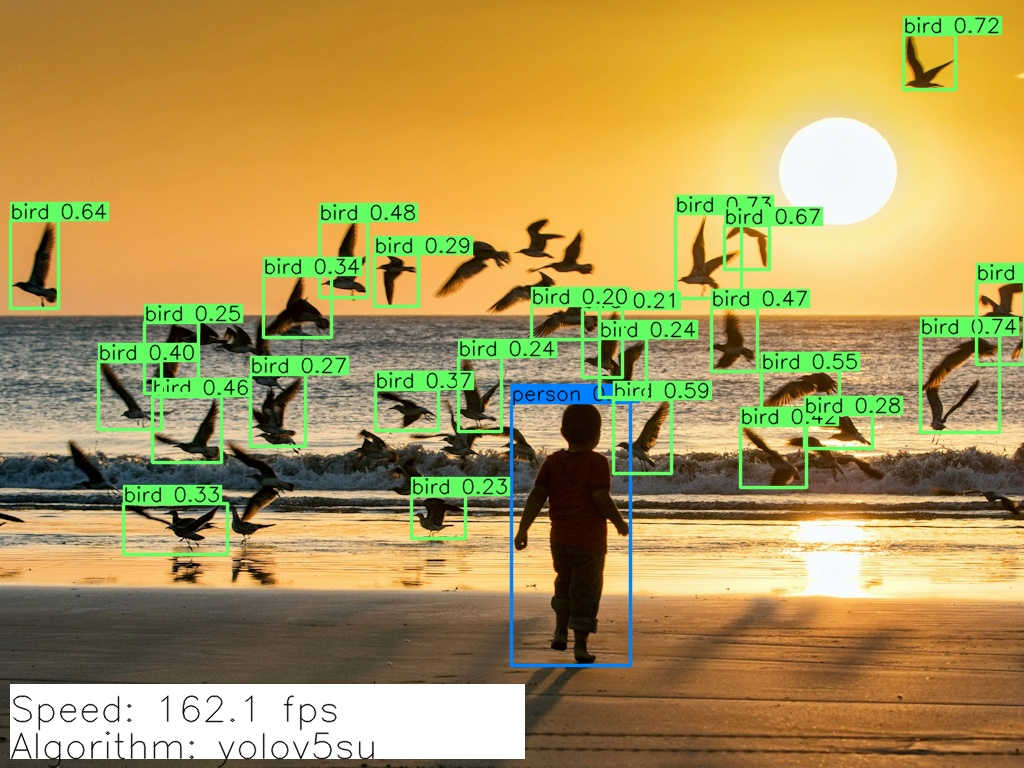

In [17]:
from IPython.display import display
from PIL import Image
display(Image.open("birds.jpg"))